Install/Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
%matplotlib inline

Load dataset

In [2]:
from google.colab import files

uploaded = files.upload()  # This opens a file picker — select Mall_Customers.csv

# Get the filename automatically (in case it's not exactly "Mall_Customers.csv")
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
df.head()

Saving Mall_Customers.csv to Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Data Understanding

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn Names:", df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
df.describe(include='all')

Shape of dataset: (200, 5)

Column Names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Summary Statistics:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


Identify feature types

In [4]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical Features: ['Gender']


Check missing values

In [5]:
print("Missing values per column:\n")
print(df.isnull().sum())

Missing values per column:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Drop unnecessary columns & encode categorical

In [6]:
# Drop CustomerID as it holds no analytical value
df_clean = df.drop(columns=['CustomerID'])

# Encode Gender (categorical) using Label Encoding
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])  # Male=1, Female=0

df_clean.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


Standardize numerical features

In [7]:
features_to_scale = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[features_to_scale])

scaled_df = pd.DataFrame(scaled_data, columns=features_to_scale)
scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


Elbow Method

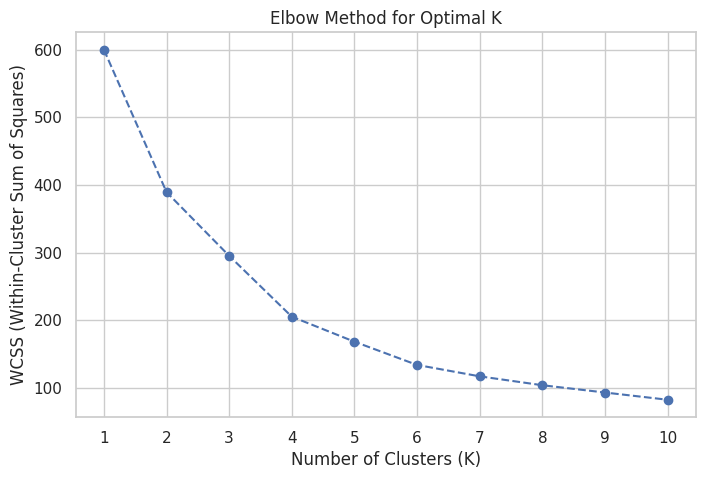

In [8]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.show()

Train final K-Means model

In [9]:
optimal_k = 5

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(scaled_df)

df_clean['Cluster'] = cluster_labels
df_clean.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,1
1,1,21,15,81,1
2,0,20,16,6,0
3,0,23,16,77,1
4,0,31,17,40,1


Apply PCA (reduce to 2 components)

In [10]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df)

df_clean['PCA1'] = pca_result[:, 0]
df_clean['PCA2'] = pca_result[:, 1]

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained by 2 Components:", sum(pca.explained_variance_ratio_))

df_clean.head()

Explained Variance Ratio: [0.44266167 0.33308378]
Total Variance Explained by 2 Components: 0.7757454566976747


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,PCA1,PCA2
0,1,19,15,39,1,-0.615720,-1.763481
1,1,21,15,81,1,-1.665793,-1.820747
2,0,20,16,6,0,0.337862,-1.674799
3,0,23,16,77,1,-1.456573,-1.772430
4,0,31,17,40,1,-0.038465,-1.662740


Scatter plot of clusters (Income vs Spending Score)

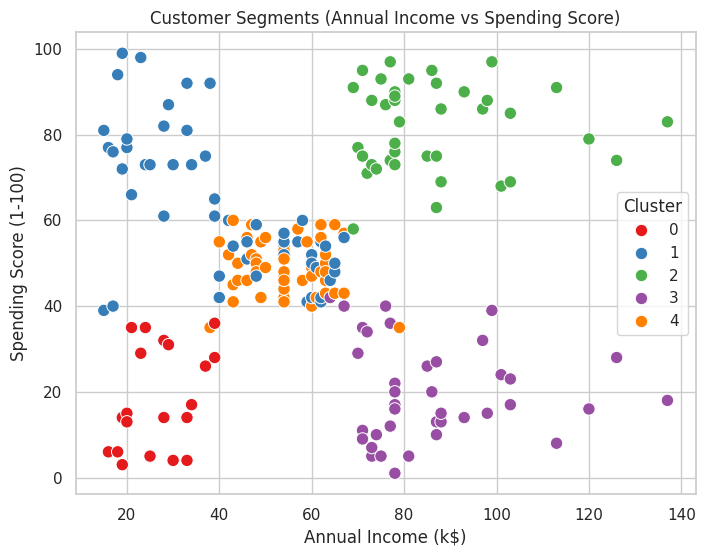

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_clean,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=80
)
plt.title('Customer Segments (Annual Income vs Spending Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

PCA visualization with cluster labels

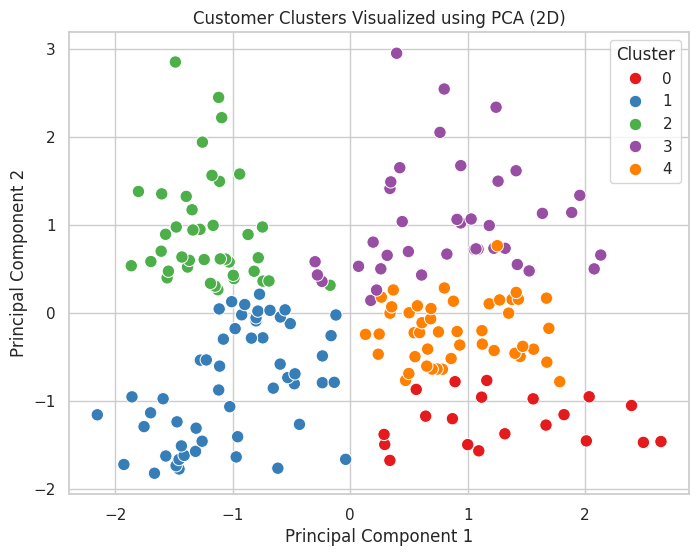

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_clean,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1',
    s=80
)
plt.title('Customer Clusters Visualized using PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

Cluster profiling

In [13]:
cluster_summary = df_clean.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Average feature values per cluster:\n")
cluster_summary

Average feature values per cluster:



,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


## Observations

1. **Optimal number of clusters:** The Elbow Curve shows a clear bend at K=5, after which WCSS decreases only marginally — indicating 5 is the optimal number of customer segments.

2. **Role of PCA:** The dataset has 3+ standardized features (Age, Income, Spending Score), making direct visualization difficult beyond 2D. PCA reduces this to 2 principal components while retaining most of the variance, allowing the clusters to be plotted and visually inspected for separation.

3. **Customer group characteristics:** Based on the cluster profiling table, groups differ meaningfully — e.g. one cluster represents high-income, high-spending customers (ideal marketing target), another represents low-income, low-spending customers, and others fall in between with varying age profiles.

4. **Cluster separation:** The PCA scatter plot shows fairly distinct groupings, confirming that K-Means found meaningful structure in the customer data rather than arbitrary splits.

## Conclusion

This project applied K-Means Clustering to segment mall customers based on their age, annual income, and spending score. Using the Elbow Method, five clusters were identified as optimal, each representing a distinct customer profile — ranging from high-income high-spenders to budget-conscious shoppers. Principal Component Analysis was used to reduce the standardized features to two dimensions, enabling clear visualization of how well-separated these segments are.

From a business perspective, this segmentation allows the mall's management to design targeted marketing campaigns — for instance, offering premium loyalty programs to high-value customers and discount-driven promotions to price-sensitive segments. This improves marketing ROI and customer retention.

A key limitation of K-Means is that it requires the number of clusters to be specified in advance and assumes roughly spherical, equally-sized clusters, which may not always reflect real customer behavior. On the other hand, PCA's main advantage is that it simplifies high-dimensional data into interpretable components while preserving most of the variance, making pattern visualization and communication much easier.